# Olist E-Commerce Sales & Customer Analysis

## Project Objective

The objective of this project is to analyze e-commerce sales data to understand sales performance, customer behavior, product performance, delivery patterns, and customer reviews.

The analysis will help identify key business trends and generate actionable insights using Python, Pandas, NumPy, and Matplotlib.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
orders= pd.read_csv("olist_orders_dataset.csv")
customers= pd.read_csv("olist_customers_dataset.csv")
order_items=pd.read_csv("olist_order_items_dataset.csv")
payments=pd.read_csv("olist_order_payments_dataset.csv")
reviews=pd.read_csv("olist_order_reviews_dataset.csv")
products=pd.read_csv( "olist_products_dataset.csv")
sellers=pd.read_csv("olist_sellers_dataset.csv")
geolocation=pd.read_csv("olist_geolocation_dataset.csv")
category_translation=pd.read_csv("product_category_name_translation.csv")


# Data understanding

In [ ]:
all_dfs = [orders, customers, order_items, payments, reviews,
           products, sellers, geolocation, category_translation]

all_names = ['orders', 'customers', 'order_items', 'payments', 'reviews',
             'products', 'sellers', 'geolocation', 'translation']

for name, df in zip(all_names, all_dfs):
    print("\n" + "=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    print("\nInfo:")
    df.info()

    print("\nFirst 2 Rows:")
    display(df.head(2))


ORDERS
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

First 2 Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00



CUSTOMERS
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

First 2 Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP



ORDER_ITEMS
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB

First 2 Rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP



GEOLOCATION
Shape: (1000163, 5)
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB

First 2 Rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP



TRANSLATION
Shape: (71, 2)
Columns: ['product_category_name', 'product_category_name_english']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB

First 2 Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


# Missing Values Check

In [ ]:
all_dfs=[orders, customers, order_items, payments, reviews,products, sellers, geolocation, category_translation]
all_names=['orders', 'customers', 'order_items', 'payments', 'reviews','products','sellers', 'geolocation','category_translation']
for name,df in zip(all_names, all_dfs):
    print("\n" + "=" * 60)
    print(f"{name.upper()}- Missing Values")
    print("=" *60)
    missing = df.isnull().sum()
    print(missing[missing>0])


ORDERS- Missing Values
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

CUSTOMERS- Missing Values
Series([], dtype: int64)

ORDER_ITEMS- Missing Values
Series([], dtype: int64)

PAYMENTS- Missing Values
Series([], dtype: int64)

REVIEWS- Missing Values
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS- Missing Values
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS- Missing Values
Series([], dtype: int64)

GEOLOCATION- Missing Values
Series([], dtype: int64)

CATEGORY_TRANSLATION- Missing Values
Series([], dtype: int64)


# Duplicate Values Check

In [ ]:
for name, df in zip(all_names, all_dfs):
    print("\n" + "=" * 60)
    print(f"{name.upper()}- Duplicate Rows")
    print("=" * 60)
    print("Duplicate rows:",
      df.duplicated().sum())


ORDERS- Duplicate Rows
Duplicate rows: 0

CUSTOMERS- Duplicate Rows
Duplicate rows: 0

ORDER_ITEMS- Duplicate Rows
Duplicate rows: 0

PAYMENTS- Duplicate Rows
Duplicate rows: 0

REVIEWS- Duplicate Rows
Duplicate rows: 0

PRODUCTS- Duplicate Rows
Duplicate rows: 0

SELLERS- Duplicate Rows
Duplicate rows: 0

GEOLOCATION- Duplicate Rows
Duplicate rows: 261831

CATEGORY_TRANSLATION- Duplicate Rows
Duplicate rows: 0


# Data Types Check

In [ ]:
for name,df in zip(all_names, all_dfs):
    print("\n" +"=" *60)
    print(f"{name.upper()}-Data Types")
    print("=" * 60)
    print(df.dtypes)


ORDERS-Data Types
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

CUSTOMERS-Data Types
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

ORDER_ITEMS-Data Types
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

PAYMENTS-Data Types
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS-Data T

# Date Conversion

In [ ]:
# Convert date columns in Orders table
orders_date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']
for col in orders_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Convert date column in Order Items table
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'],errors='coerce')

# Convert date columns in Reviews table
reviews_date_cols = [
    'review_creation_date','review_answer_timestamp']
for col in reviews_date_cols:
    reviews[col] = pd.to_datetime(reviews[col],errors='coerce')

print("Date conversion completed successfully!")

Date conversion completed successfully!


In [ ]:
print("ORDERS DATE TYPES")
print(orders[[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].dtypes)


print("\nORDER ITEMS DATE TYPE")
print(order_items['shipping_limit_date'].dtype)


print("\nREVIEWS DATE TYPES")
print(reviews[[
    'review_creation_date',
    'review_answer_timestamp'
]].dtypes)

ORDERS DATE TYPES
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

ORDER ITEMS DATE TYPE
datetime64[us]

REVIEWS DATE TYPES
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object


# Duplicate Check - Geolocation
The geolocation dataset contains exact duplicate rows. These duplicates records will be removed to avoid redundancy and maintain data quality.

In [ ]:
geolocation[geolocation.duplicated()].head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
72,1046,-23.545320,-46.644069,sao paulo,SP
79,1050,-23.549854,-46.643139,sao paulo,SP
80,1032,-23.540775,-46.635515,sao paulo,SP
82,1046,-23.546081,-46.644820,sao paulo,SP
86,1048,-23.547449,-46.640169,são paulo,SP


# Geolocation Data Cleaning

In [ ]:
geolocation['geolocation_city']= geolocation['geolocation_city'].str.strip()

## Duplicate Check - Geolocation

In [ ]:
geolocation = geolocation.drop_duplicates().copy()
print("Duplicate rows remaining:",geolocation.duplicated().sum())

Duplicate rows remaining: 0


# Primary Key Uniqueness Check

In [ ]:
print("Orders - order_id:")
print("Unique IDs:", orders['order_id'].nunique())
print("Total rows:", len(orders))

print("\nCustomers - customer_id:")
print("Unique IDs:", customers['customer_id'].nunique())
print("Total rows:", len(customers))

print("\nProducts - product_id:")
print("Unique IDs:", products['product_id'].nunique())
print("Total rows:", len(products))

print("\nSellers - seller_id:")
print("Unique IDs:", sellers['seller_id'].nunique())
print("Total rows:", len(sellers))

Orders - order_id:
Unique IDs: 99441
Total rows: 99441

Customers - customer_id:
Unique IDs: 99441
Total rows: 99441

Products - product_id:
Unique IDs: 32951
Total rows: 32951

Sellers - seller_id:
Unique IDs: 3095
Total rows: 3095


# Foreign Key Check

In [ ]:
print(
    "Order IDs missing in Orders:",
    (~order_items['order_id'].isin(orders['order_id'])).sum()
)

print(
    "Customer IDs missing in Customers:",
    (~orders['customer_id'].isin(customers['customer_id'])).sum()
)

print(
    "Product IDs missing in Products:",
    (~order_items['product_id'].isin(products['product_id'])).sum()
)

print(
    "Seller IDs missing in Sellers:",
    (~order_items['seller_id'].isin(sellers['seller_id'])).sum()
)

Order IDs missing in Orders: 0
Customer IDs missing in Customers: 0
Product IDs missing in Products: 0
Seller IDs missing in Sellers: 0


# Order-Level Sales Summary

In [ ]:
order_items_summary= order_items.groupby('order_id',as_index=False).agg(
    total_items= ('order_item_id','count'),
    total_product=('price','sum'),
    total_freight_value=('freight_value','sum')
)
order_items_summary.head()

,order_id,total_items,total_product,total_freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


## Payment Summary

In [ ]:
payments_summary = payments.groupby('order_id',as_index=False).agg(
    total_payment_value= ('payment_value','sum')
)
(payments_summary.head())

,order_id,total_payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


## Core Order-Level Dataset

In [ ]:
sales_data = orders.merge(customers,on ='customer_id',how= 'left').merge(order_items_summary,on= 'order_id',how = 'left').merge(payments_summary,on= 'order_id',how= 'left')
sales_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_items,total_product,total_freight_value,total_payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,19.90,8.72,28.62


## Validate Order-Level Dataset

In [ ]:
print('Total_Rows:',len(sales_data))
print('Unique_Orders:',sales_data['order_id'].nunique())
print('Duplicate_order_rows:',sales_data['order_id'].duplicated().sum())

Total_Rows: 99441
Unique_Orders: 99441
Duplicate_order_rows: 0


# Sales Performance Analysis

In [ ]:
total_orders= sales_data['order_id'].nunique()
total_Sales= sales_data['total_product'].sum()
total_freight = sales_data['total_freight_value'].sum()
average_order_value= total_Sales/total_orders

print('Total_Orders:',total_orders)
print('Total_Sales_Value:',round(total_Sales,2))
print('Total_Freight_Value:',round(total_freight,2))
print('Average_Order_value:',round(average_order_value,2))


Total_Orders: 99441
Total_Sales_Value: 13591643.7
Total_Freight_Value: 2251909.54
Average_Order_value: 136.68


## Monthly Sales Trend

In [ ]:
monthly_sales = sales_data.groupby(sales_data['order_purchase_timestamp'].dt.to_period('M')).agg(
    total_sales= ('total_product','sum'),
    total_orders= ('order_id','nunique')
).reset_index()
monthly_sales.head()

,order_purchase_timestamp,total_sales,total_orders
0,2016-09,267.36,4
1,2016-10,49507.66,324
2,2016-12,10.90,1
3,2017-01,120312.87,800
4,2017-02,247303.02,1780


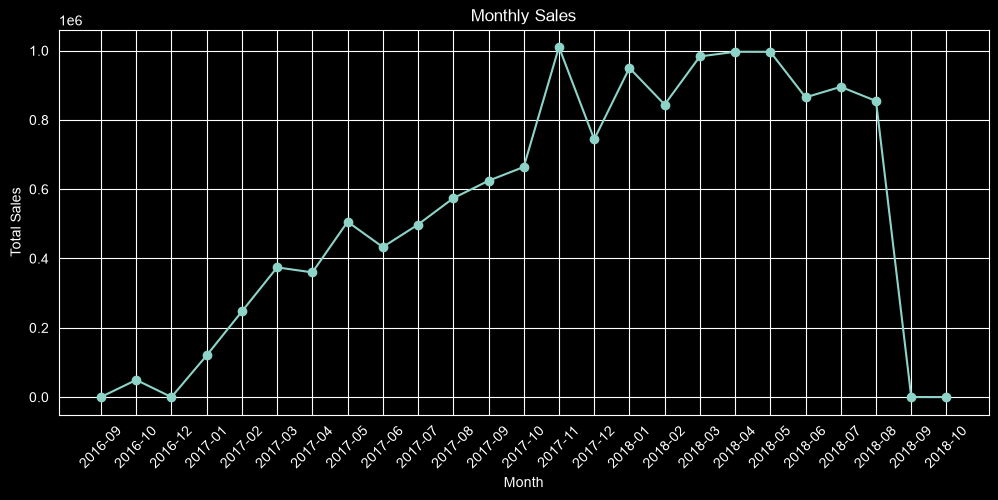

In [ ]:
plt.figure(figsize =(12,5))
plt.plot(monthly_sales['order_purchase_timestamp'].astype(str),
         monthly_sales['total_sales'],
         marker='o',)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Monthly Orders Trend

In [ ]:
monthly_orders = sales_data.groupby(sales_data['order_purchase_timestamp'].dt.to_period('M')).agg(total_orders= ('order_id','nunique')).reset_index()
monthly_orders.head()

,order_purchase_timestamp,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


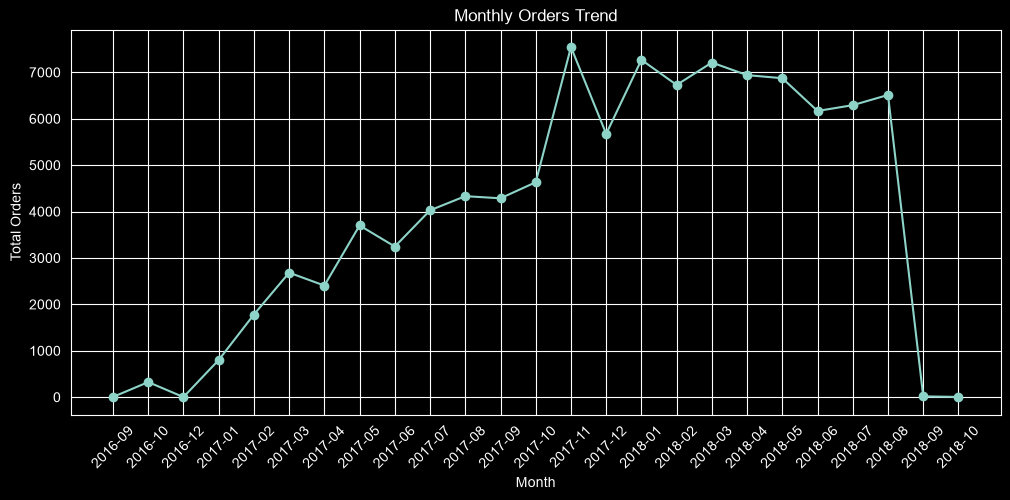

In [ ]:
plt.figure(figsize =(12,5))
plt.plot(monthly_orders['order_purchase_timestamp'].astype(str),monthly_orders['total_orders'],
         marker='o',)
plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Order Status Analysis

In [ ]:
order_status = orders['order_status'].value_counts().reset_index()
order_status.columns = ['order_status','total_orders']
order_status.head()

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314


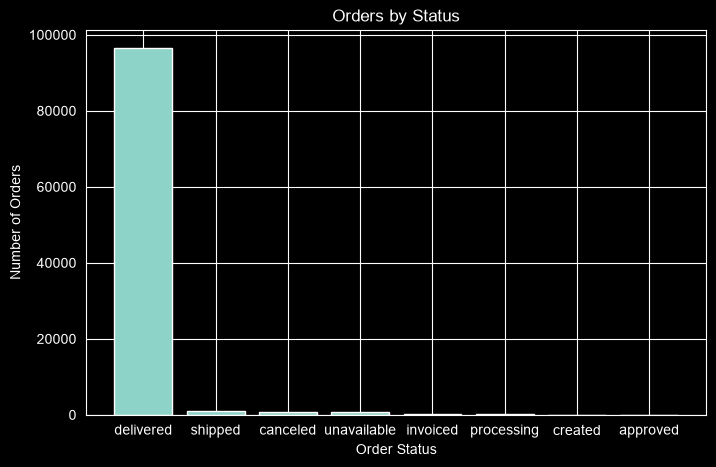

In [ ]:
plt.figure(figsize =(8,5))
plt.bar(order_status['order_status'],order_status['total_orders'])
plt.title('Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.show()

## Payment Method Analysis

In [ ]:
payment_method = payments.groupby('payment_type',as_index= False).agg(
    total_payment = ('payment_value','sum'),
    total_orders = ('order_id','nunique')
)
payment_method

,payment_type,total_payment,total_orders
0,boleto,2869361.27,19784
1,credit_card,12542084.19,76505
2,debit_card,217989.79,1528
3,not_defined,0.00,3
4,voucher,379436.87,3866


### Payment Method Visualization

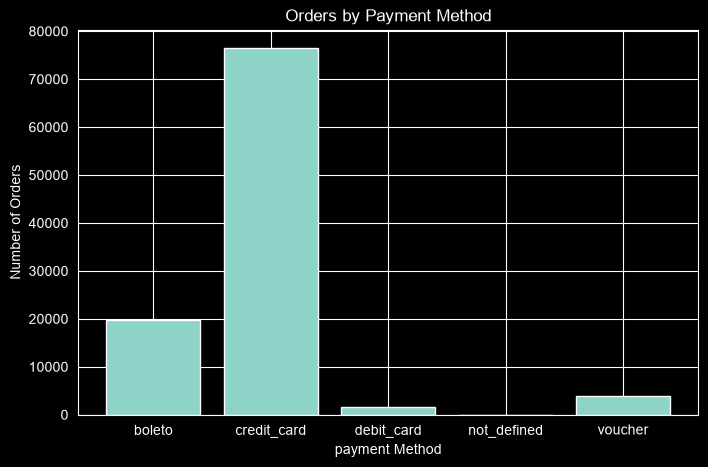

In [ ]:
plt.figure(figsize =(8,5))
plt.bar(payment_method['payment_type'],
        payment_method['total_orders'])
plt.title('Orders by Payment Method')
plt.xlabel('payment Method')
plt.ylabel('Number of Orders')
plt.show()

# Product Performance Analysis

In [ ]:
category_sales = order_items.merge(products[['product_id','product_category_name']],on ='product_id',how= 'left').merge(category_translation,on= 'product_category_name',how= 'left')

category_sales_summary = category_sales.groupby('product_category_name_english',as_index=False).agg(
    total_sales = ('price',sum),
    total_orders = ('order_id','nunique')
).sort_values(
    'total_sales' ,ascending=False
)
category_sales_summary.head(10)


,product_category_name_english,total_sales,total_orders
43,health_beauty,1258681.34,8836
70,watches_gifts,1205005.68,5624
7,bed_bath_table,1036988.68,9417
65,sports_leisure,988048.97,7720
15,computers_accessories,911954.32,6689
39,furniture_decor,729762.49,6449
20,cool_stuff,635290.85,3632
49,housewares,632248.66,5884
5,auto,592720.11,3897
42,garden_tools,485256.46,3518


## Top 10 Product Categories by Sales

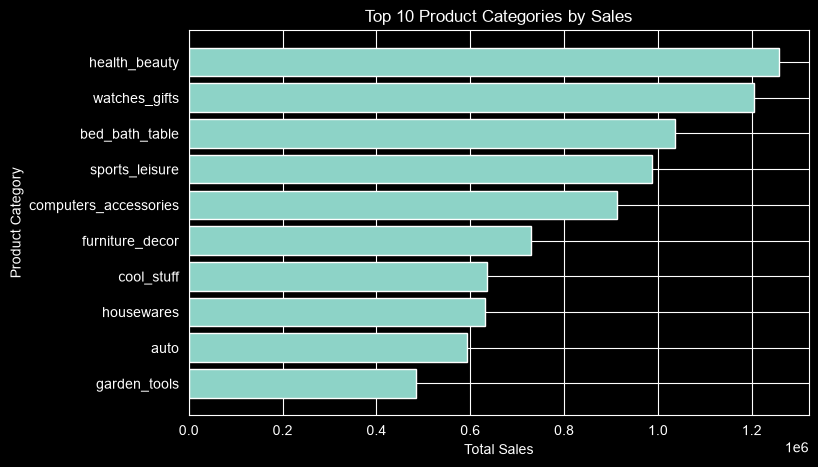

In [ ]:
top_categories_sales = category_sales_summary.head(10)
plt.figure(figsize=(8,5))
plt.barh( top_categories_sales['product_category_name_english'],
    top_categories_sales['total_sales']
)
plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

## Top Product Categories by Orders

In [ ]:
top_categories_orders = category_sales_summary.sort_values('total_orders',ascending=False).head(10)
top_categories_orders

,product_category_name_english,total_sales,total_orders
7,bed_bath_table,1036988.68,9417
43,health_beauty,1258681.34,8836
65,sports_leisure,988048.97,7720
15,computers_accessories,911954.32,6689
39,furniture_decor,729762.49,6449
49,housewares,632248.66,5884
70,watches_gifts,1205005.68,5624
68,telephony,323667.53,4199
5,auto,592720.11,3897
69,toys,483946.60,3886


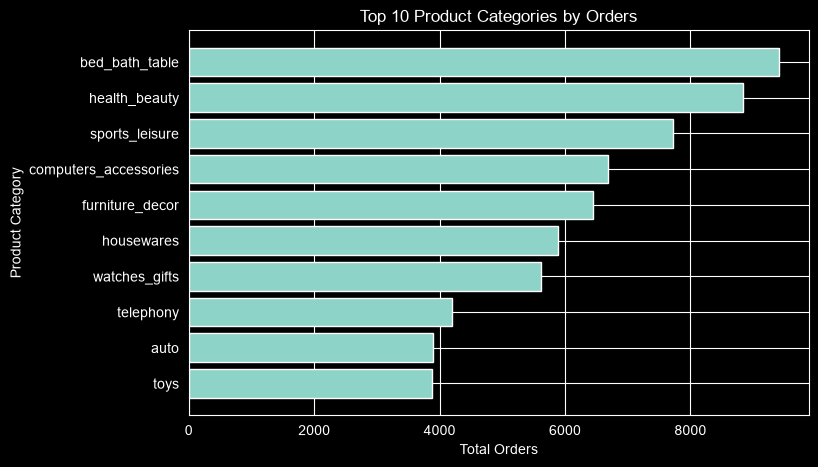

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(top_categories_orders['product_category_name_english'],top_categories_orders['total_orders'])
plt.title('Top 10 Product Categories by Orders')
plt.xlabel('Total Orders')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

# Customer Behavior Analysis

In [ ]:
customer_behaviour = sales_data.groupby('customer_unique_id').agg(
    total_orders= ('order_id','nunique'),
    total_spent = ('total_product','sum')
).reset_index()
customer_behaviour.head(10)


,customer_unique_id,total_orders,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90
2,0000f46a3911fa3c0805444483337064,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,180.00
5,0004bd2a26a76fe21f786e4fbd80607f,1,154.00
6,00050ab1314c0e55a6ca13cf7181fecf,1,27.99
7,00053a61a98854899e70ed204dd4bafe,1,382.00
8,0005e1862207bf6ccc02e4228effd9a0,1,135.00
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,104.90


## Repeat vs One-Time Customers

In [ ]:
repeat_customers = (customer_behaviour['total_orders']>1).sum()
one_time_customers = (customer_behaviour['total_orders']==1).sum()
total_customers = len(customer_behaviour)
repeat_customer_rate = (repeat_customers/total_customers) * 100

print('One-Time Customers:',one_time_customers)
print('Repeat Customers:',repeat_customers)
print('Repeat Customer Rate:',round(repeat_customer_rate,2),"%")

One-Time Customers: 93099
Repeat Customers: 2997
Repeat Customer Rate: 3.12 %


## Customer Spending Analysis

In [ ]:
customer_spending = customer_behaviour.groupby('total_orders').agg(
    total_customers = ('customer_unique_id','count'),
    total_spent= ('total_spent','sum')
).reset_index()
customer_spending

,total_orders,total_customers,total_spent
0,1,93099,12812821.73
1,2,2745,672753.59
2,3,203,74173.11
3,4,30,19667.58
4,5,8,5130.54
5,6,6,3086.66
6,7,3,2280.02
7,9,1,1000.85
8,17,1,729.62


### Customer Spending by Order Frequency

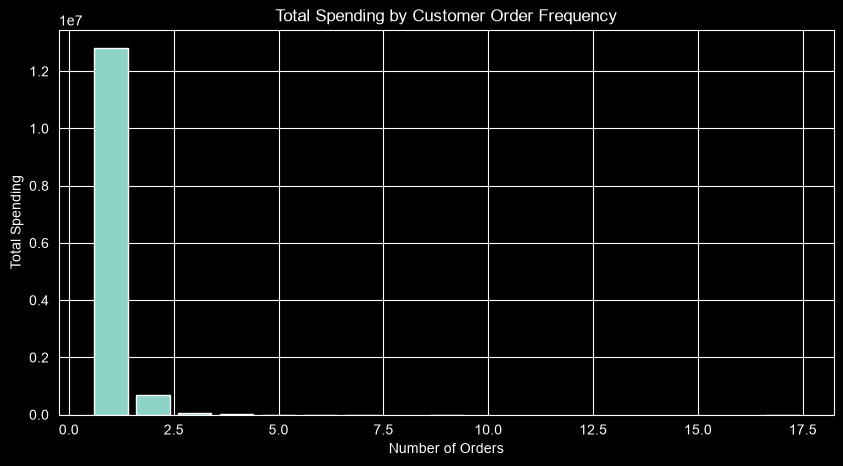

In [ ]:
plt.figure(figsize =(10,5))
plt.bar(customer_spending['total_orders'],customer_spending['total_spent'])
plt.title('Total Spending by Customer Order Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spending')
plt.show()

### Top 10 Customers by Spending

In [ ]:
top_customers = customer_behaviour.sort_values('total_spent',ascending=False).head(10)
top_customers

,customer_unique_id,total_orders,total_spent
3826,0a0a92112bd4c708ca5fde585afaa872,1,13440.0
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0
26205,459bef486812aa25204be022145caa62,1,6729.0
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0
24121,4007669dec559734d6f53e029e360987,1,5934.6
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0
35070,5d0a2980b292d049061542014e8960bf,1,4599.9
27441,48e1ac109decbb87765a3eade6854098,1,4590.0


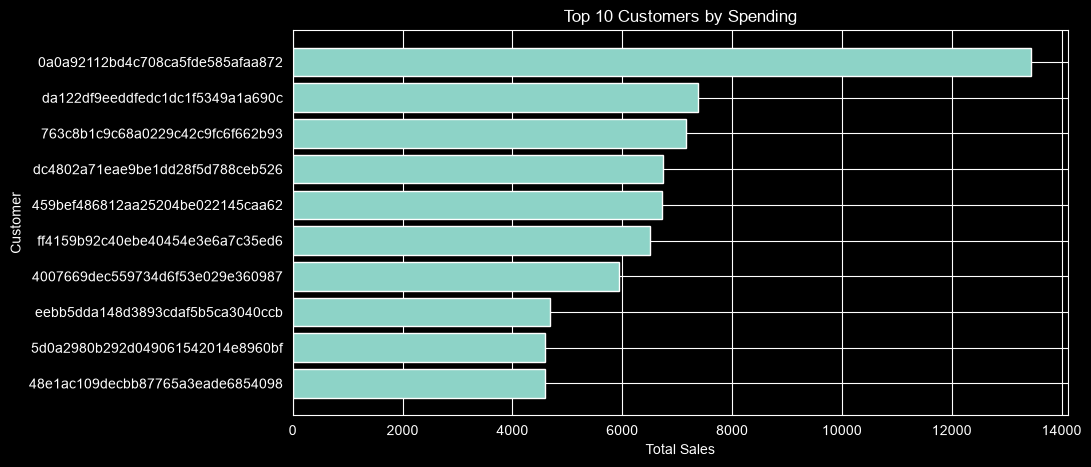

In [ ]:
plt.figure(figsize =(10,5))
plt.barh(top_customers['customer_unique_id'],top_customers['total_spent'])
plt.title('Top 10 Customers by Spending')
plt.xlabel('Total Sales')
plt.ylabel('Customer')
plt.gca().invert_yaxis()
plt.show()

# Delivery Performance Analysis

In [ ]:
delivery_data= orders[['order_id','order_purchase_timestamp','order_delivered_customer_date',
                       'order_estimated_delivery_date']].copy()
delivery_data.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


## Actual Delivery Time

In [ ]:
delivery_data['delivery_days']=(delivery_data['order_delivered_customer_date']-delivery_data['order_purchase_timestamp']).dt.days
delivery_data.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0


## Average Delivery Time

In [ ]:
average_delivery_time = delivery_data['delivery_days'].mean()
print('Average Delivery Time:',round(average_delivery_time,2),'Days')

Average Delivery Time: 12.09 Days


## Actual vs Estimated Delivery

In [ ]:
delivery_data['estimated_days'] = (delivery_data['order_estimated_delivery_date']-delivery_data['order_purchase_timestamp']).dt.days
delivery_data['delivery_difference'] = (delivery_data['estimated_days']-delivery_data['delivery_days'])
delivery_data.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_days,delivery_difference
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,15,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,19,6.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,26,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,26,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,12,10.0


## Delivery Status Analysis

In [ ]:
delivery_data['delivery_status'] = np.where(delivery_data['order_delivered_customer_date'].isna(), 'Not Delivered',np.where(delivery_data['order_delivered_customer_date'] <= delivery_data['order_estimated_delivery_date'],'On Time','Late'))
delivery_data['delivery_status'].value_counts()

delivery_status
On Time          88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64

### On-Time Delivery Rate

In [201]:
on_time_orders = (delivery_data['delivery_status']=='On Time').sum()
total_Delivered_orders= delivery_data['delivery_status'].notna().sum()
on_time_delivery_Rate = (on_time_orders/total_Delivered_orders) *100
print('On-Time Delivery Rate:',round(on_time_delivery_Rate,2),"%")

On-Time Delivery Rate: 89.15 %


# Customer Review Analysis

In [202]:
review_score_distribution = reviews['review_score'].value_counts().sort_index()
review_score_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

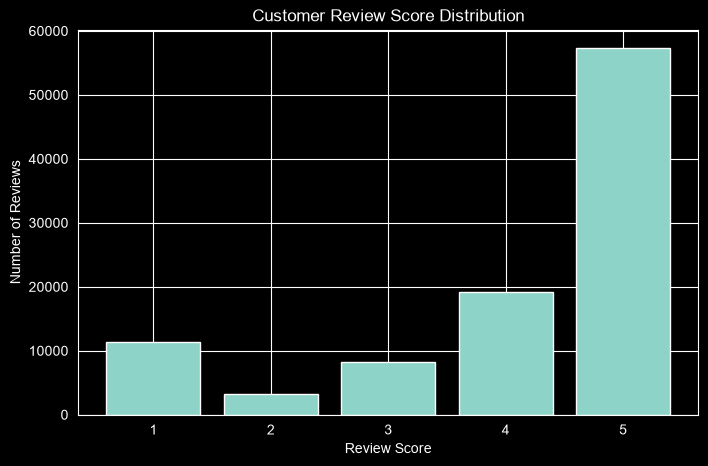

In [203]:
plt.figure(figsize =(8,5))
plt.bar(review_score_distribution.index,review_score_distribution.values)
plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

## Average Review Score

In [204]:
average_review_score = reviews['review_score'].mean()
print('Average Review Score:',round(average_review_score,2))

Average Review Score: 4.09


## Review Score vs Delivery Time

In [205]:
review_delivery = reviews.merge(delivery_data[['order_id','delivery_days']],on='order_id',how='inner')
review_delivery.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_days
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,6.0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,9.0
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,13.0
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,10.0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,18.0


### Average Review Score by Delivery Time

In [206]:
review_delivery['delivery_group'] = pd.cut(review_delivery['delivery_days'],bins=[0,7,14,21,float('inf')],labels=['0-7 days','8-14 days','15-21 days','22+ days'])
review_by_delivery = review_delivery.groupby('delivery_group')['review_score'].mean()
review_by_delivery

delivery_group
0-7 days      4.408292
8-14 days     4.288356
15-21 days    4.102334
22+ days      3.006057
Name: review_score, dtype: float64

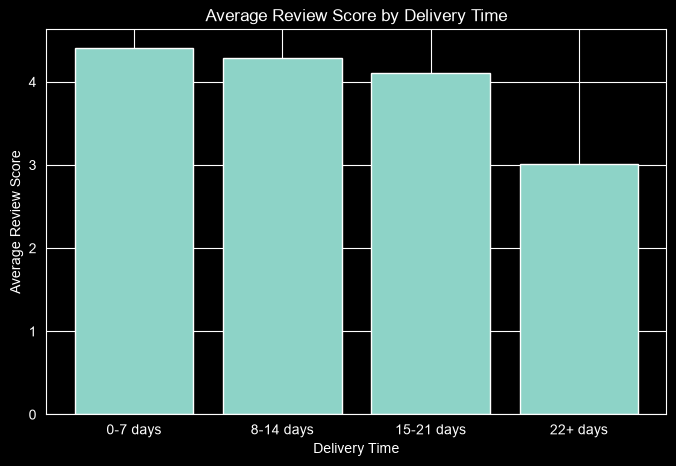

In [207]:
plt.figure(figsize =(8,5))
plt.bar(review_by_delivery.index,review_by_delivery.values)
plt.title('Average Review Score by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Average Review Score')
plt.show()

# Geographic Sales Analysis

In [208]:
sales_by_state = sales_data.groupby('customer_state')['total_product'].sum().sort_values(ascending=False)
sales_by_state

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
PE     262788.03
CE     227254.71
PA     178947.81
MT     156453.53
MA     119648.22
MS     116812.64
PB     115268.08
PI      86914.08
RN      83034.98
AL      80314.81
SE      58920.85
TO      49621.74
RO      46140.64
AM      22356.84
AC      15982.95
AP      13474.30
RR       7829.43
Name: total_product, dtype: float64

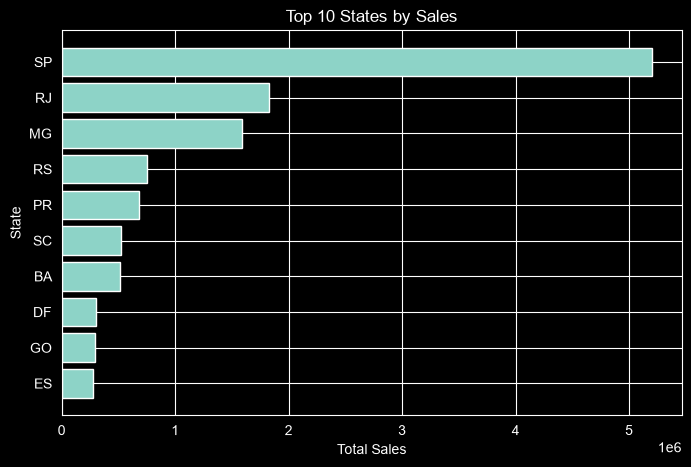

In [209]:
top_states = sales_by_state.head(10)
plt.figure(figsize =(8,5))
plt.barh(top_states.index,top_states.values)
plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.gca().invert_yaxis()
plt.show()

# Key Business Insights and Conclusion
 - Customer satisfaction was generally high, with 5-star reviews being the most common. However, average review scores tended to decrease as delivery time increased, especially for orders taking 22+ days. This suggests that longer delivery times are associated with lower customer satisfaction.
 - Sales were concentrated in a limited number of Brazilian states, indicating that a few regions contributed significantly to overall revenue.
- Product categories showed differences in both sales and order volume, indicating that some categories were more important to the business than others.
- Monthly Sales and order volume changed across months, showing that customer demand was not the same throughout the year.